In [20]:
import os 
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
ALGS_TEST = ['RDSGD','ORACLE']

Experiment 1: Test Accuracy Tables, analyzing why convergence failed for LF on RR graph

In [4]:
exp = Path().resolve()
run_dir = os.path.join(exp,'default')
os.listdir(run_dir)

['watts-strogatz',
 'clf_sim_data_watts-strogatz_5.pkl.gz',
 'erdos-renyi',
 'config.json',
 'clf_sim_data_erdos-renyi_5.pkl.gz',
 'geometric',
 'sys_metrics_5.csv',
 'clf_sim_data_geometric_5.pkl.gz',
 'clf_sim_data_random-regular_5.pkl.gz',
 'clf_metrics_5.csv',
 'random-regular']

In [34]:
rr_dir = os.path.join(exp,'default','erdos-renyi')
os.listdir(rr_dir)

['sys_sim_df_erdos-renyi_5_sign_flip.csv',
 'sys_sim_df_erdos-renyi_5_gaussian.csv',
 'sys_sim_df_erdos-renyi_5_label_flip.csv',
 'sys_sim_df_erdos-renyi_5_IPM.csv',
 'sys_sim_df_erdos-renyi_5_ALIE.csv']

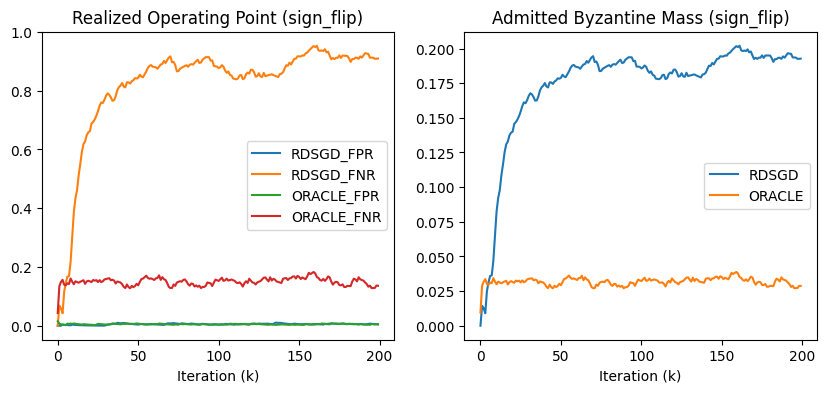

In [36]:
# Plot Realized FPR and FNR 
K = 200
graph = 'watts-strogatz'
atk = 'sign_flip'
data = os.path.join(exp,'default',graph,f'sys_sim_df_{graph}_5_{atk}.csv')
df = pd.read_csv(data).set_index('alg')
fig, ax = plt.subplots(1,2,figsize=(10,4))
for idx, alg in enumerate(ALGS_TEST):
    ax[0].plot(np.arange(200), df.loc[alg, 'gamma_k'].ewm(com=10, adjust=True).mean(), label=f'{alg}_FPR')
    ax[0].plot(np.arange(200), df.loc[alg, 'beta_k'].ewm(com=10, adjust=True).mean(), label=f'{alg}_FNR')
    ax[1].plot(np.arange(200), df.loc[alg, 'byz_w_k'].ewm(com=10, adjust=True).mean(), label=alg)
ax[0].set(title=f'Realized Operating Point ({atk})', xlabel='Iteration (k)', ylabel='')
ax[1].set(title=f'Admitted Byzantine Mass ({atk})', xlabel='Iteration (k)', ylabel='')
ax[0].legend()
ax[1].legend()
fig.savefig(os.path.join(exp,'default','images',f'realized_fpr_fnr_{graph}_5_{atk}.png'))
plt.show()